# 02 — LightGBM Salvage Shootout (v2): Multi-Target × Safe Momentum

**Task ID:** `MODEL-LGBM-SALVAGE-005`  
**Input:** `BTCUSDT_5m_structural_clean.parquet` (39 patched structural features from V1)  
**New features (Phase A):** 4 safe momentum features — all `shift(1)` verified  

## Why V1 Failed (AUC = 0.52)

Two competing hypotheses:
1. **Target too hard** — 24h path-dependent TBM with asymmetric (2.5/1.5) barriers is noisy; LightGBM cannot reliably separate TP vs SL over such a long horizon.
2. **Features too slow** — structural features describe market *geometry*, not *velocity*. A 5m model needs short-term momentum signals to distinguish directionality.

This notebook attacks both hypotheses simultaneously.

## Protocol

| Phase | Action |
|-------|---------|
| A | Augment feature set with 4 clean momentum features (micro-returns + vol slope) |
| B | Compute 3 distinct target labels (Macro TBM, Micro TBM, Fixed Horizon) |
| C | Expanded grid search — 36 configs × 3 targets = 108 fits |
| D | Regime-filtered AUC (squeeze bottom-20% + trend alignment >0.5) |

| Target | TP | SL | Horizon | Rationale |
|--------|----|----|---------|----------|
| 1 Macro TBM | 2.5×ATR | 1.5×ATR | 24h (288 bars) | Original V1 target |
| 2 Micro TBM | 1.0×ATR | 1.0×ATR | 4h (48 bars) | Scalping — less path dependency |
| 3 Fixed Horizon | — | — | 6h (72 bars), >0.3% | Pure direction, no TP/SL complexity |

**Figures:** `lab/figures/lgbm_v2/`

In [1]:
import json
import time
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import ParameterGrid

warnings.filterwarnings('ignore', category=UserWarning)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)

# ── Chronological split (same as V1) ────────────────────────────────────
TRAIN_END = '2023-12-31 23:55'
VAL_END   = '2024-12-31 23:55'

# ── Target 1: Macro TBM (unchanged from V1) ─────────────────────────────
TBM_MACRO_TP  = 2.5
TBM_MACRO_SL  = 1.5
TBM_MACRO_HOR = 288   # 24h in 5m bars

# ── Target 2: Micro TBM (symmetric, 4h horizon) ─────────────────────────
TBM_MICRO_TP  = 1.0
TBM_MICRO_SL  = 1.0
TBM_MICRO_HOR = 48    # 4h in 5m bars

# ── Target 3: Fixed Horizon Direction ───────────────────────────────────
FH_HORIZON   = 72     # 6h
FH_THRESHOLD = 0.003  # >0.3% strictly higher

# ── Expanded grid (3×3×2×2 = 36 configs) ────────────────────────────────
BASE_LGB_PARAMS = dict(
    objective         = 'binary',
    metric            = 'auc',
    verbose           = -1,
    n_jobs            = -1,
    seed              = 42,
    n_estimators      = 1500,
    min_child_samples = 50,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
)

PARAM_GRID = list(ParameterGrid({
    'num_leaves':      [15, 31, 63],
    'max_depth':       [4, 6, 8],
    'learning_rate':   [0.01, 0.05],
    'colsample_bytree':[0.5, 0.7],
}))

PROB_THRESHOLD = 0.60
FEE_ROUNDTRIP  = 0.001

print(f'Grid: {len(PARAM_GRID)} configs x 3 targets = {len(PARAM_GRID)*3} total fits')
print(f'Macro TBM : TP={TBM_MACRO_TP}xATR  SL={TBM_MACRO_SL}xATR  Horizon={TBM_MACRO_HOR} bars (24h)')
print(f'Micro TBM : TP={TBM_MICRO_TP}xATR  SL={TBM_MICRO_SL}xATR  Horizon={TBM_MICRO_HOR} bars (4h)')
print(f'Fixed Hor.: {FH_HORIZON} bars (6h)  threshold={FH_THRESHOLD:.1%}')

Grid: 36 configs x 3 targets = 108 total fits
Macro TBM : TP=2.5xATR  SL=1.5xATR  Horizon=288 bars (24h)
Micro TBM : TP=1.0xATR  SL=1.0xATR  Horizon=48 bars (4h)
Fixed Hor.: 72 bars (6h)  threshold=0.3%


In [2]:
def find_repo_root() -> Path:
    p = Path.cwd()
    while p != p.parent:
        if (p / 'pyproject.toml').exists():
            return p
        p = p.parent
    raise RuntimeError('pyproject.toml not found')

REPO_ROOT    = find_repo_root()
RAW_DIR      = REPO_ROOT / 'data' / 'raw'
FEATURES_DIR = REPO_ROOT / 'data' / 'features'
CACHE_DIR    = REPO_ROOT / 'data' / 'cache'
FIGURES_DIR  = REPO_ROOT / 'lab' / 'figures' / 'lgbm_v2'

CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

OHLCV_5M_PATH      = RAW_DIR      / 'BTCUSDT_5m.parquet'
FEATURES_CLEAN     = FEATURES_DIR / 'BTCUSDT_5m_structural_clean.parquet'
REGISTRY_PATH      = FEATURES_DIR / 'feature_registry_v2.json'
MACRO_LABELS_CACHE = CACHE_DIR    / 'BTCUSDT_5m_tbm_labels.parquet'
MICRO_LABELS_CACHE = CACHE_DIR    / 'BTCUSDT_5m_tbm_micro_labels.parquet'

print(f'REPO_ROOT   : {REPO_ROOT}')
print(f'FIGURES_DIR : {FIGURES_DIR}')
print(f'Clean feats : {FEATURES_CLEAN.exists()}')
print(f'Macro cache : {MACRO_LABELS_CACHE.exists()}')
print(f'Micro cache : {MICRO_LABELS_CACHE.exists()}')

REPO_ROOT   : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system
FIGURES_DIR : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/lab/figures/lgbm_v2
Clean feats : True
Macro cache : True
Micro cache : False


## Setup — Data Loading

In [3]:
print('Loading OHLCV (5m) ...')
df_raw = pd.read_parquet(OHLCV_5M_PATH, columns=['open', 'high', 'low', 'close', 'volume'])
if df_raw.index.tz is None:
    df_raw.index = df_raw.index.tz_localize('UTC')
print(f'  5m: {len(df_raw):,} bars  {df_raw.index[0].date()} -> {df_raw.index[-1].date()}')

print('Loading clean structural features (V1 patched) ...')
df_struct = pd.read_parquet(FEATURES_CLEAN)
print(f'  Shape: {df_struct.shape}')

with open(REGISTRY_PATH) as f:
    registry = json.load(f)
STRUCT_FEATURES = registry['ablation_subsets']['all']
print(f'  Structural features from registry: {len(STRUCT_FEATURES)}')

print('Loading Macro TBM labels (cached from V1) ...')
macro_labels = pd.read_parquet(MACRO_LABELS_CACHE)['label']
pos_rate = macro_labels.eq(1).mean()
print(f'  Labels: {len(macro_labels):,}  pos_rate={pos_rate:.3f}')

Loading OHLCV (5m) ...
  5m: 923,248 bars  2017-08-17 -> 2026-05-27
Loading clean structural features (V1 patched) ...
  Shape: (920748, 39)
  Structural features from registry: 39
Loading Macro TBM labels (cached from V1) ...
  Labels: 920,748  pos_rate=0.371


## Phase A — Safe Momentum Features

Four new features appended to the 39-feature Omni set.
All use `.shift(1)` so the value at bar `t` reflects only data up to bar `t-1`.

| Feature | Definition | Shift applied |
|---------|------------|---------------|
| `mom_ret_15m` | 3-bar close pct change | `.shift(1)` |
| `mom_ret_30m` | 6-bar close pct change | `.shift(1)` |
| `mom_ret_1h`  | 12-bar close pct change | `.shift(1)` |
| `mom_vol_slope_5bar` | 5-bar mean of bar-to-bar volume delta, z-scored | `.shift(1)` |

Leak assertion: `|corr(feature[t], fwd_1bar_return[t])| < 0.05`

In [4]:
def build_momentum_features(df5m: pd.DataFrame) -> pd.DataFrame:
    close  = df5m['close']
    volume = df5m['volume']
    feats  = pd.DataFrame(index=df5m.index, dtype='float32')

    # Micro-returns: pct_change ending at bar t-1 (shift delays by one)
    for n_bars, tag in [(3, '15m'), (6, '30m'), (12, '1h')]:
        feats[f'mom_ret_{tag}'] = close.pct_change(n_bars).shift(1).astype('float32')

    # 5-bar volume acceleration: rolling mean of bar-to-bar delta, z-scored
    vol_diff  = volume.diff(1)
    vol_std   = volume.rolling(72, min_periods=36).std() + 1e-8
    vol_slope = vol_diff.rolling(5, min_periods=3).mean() / vol_std
    feats['mom_vol_slope_5bar'] = vol_slope.shift(1).clip(-5, 5).astype('float32')

    return feats


print('Building momentum features ...')
df_mom = build_momentum_features(df_raw)
print(f'  Shape: {df_mom.shape}  |  NaN rows: {df_mom.isna().any(axis=1).sum():,}')
print(f'  Columns: {df_mom.columns.tolist()}')

# ── Explicit shift(1) sanity check ───────────────────────────────────────
close_arr = df_raw['close'].values
fwd1 = np.full(len(close_arr), np.nan)
fwd1[:-1] = close_arr[1:] / close_arr[:-1] - 1

print()
print('Shift(1) sanity check — |corr(feature[t], fwd_1bar_return[t])|')
print('  (>0.05 at 1-bar lag indicates possible lookahead bias)')
all_pass = True
for col in df_mom.columns:
    arr   = df_mom[col].values
    valid = ~(np.isnan(arr) | np.isnan(fwd1))
    r     = abs(np.corrcoef(arr[valid], fwd1[valid])[0, 1])
    flag  = 'OK' if r < 0.05 else 'POSSIBLE LEAK'
    print(f'  {col:<25}  |r| = {r:.5f}  {flag}')
    if r >= 0.10:
        all_pass = False

assert all_pass, 'One or more momentum features failed the shift(1) leak assertion!'
print()
print('All momentum features pass shift(1) leak assertion.')

Building momentum features ...
  Shape: (923248, 4)  |  NaN rows: 36
  Columns: ['mom_ret_15m', 'mom_ret_30m', 'mom_ret_1h', 'mom_vol_slope_5bar']

Shift(1) sanity check — |corr(feature[t], fwd_1bar_return[t])|
  (>0.05 at 1-bar lag indicates possible lookahead bias)
  mom_ret_15m                |r| = 0.00830  OK
  mom_ret_30m                |r| = 0.01323  OK
  mom_ret_1h                 |r| = 0.01464  OK
  mom_vol_slope_5bar         |r| = 0.00155  OK

All momentum features pass shift(1) leak assertion.


## Phase B — Label Construction

Compute all three target labels on the same dataset.

In [5]:
# Inner join: OHLCV + structural features + momentum features
df_base = df_raw.join(df_struct, how='inner')
df_base = df_base.join(df_mom, how='inner')
df_base.dropna(subset=STRUCT_FEATURES, inplace=True)

MOM_FEATURES = df_mom.columns.tolist()
ALL_FEATURES = STRUCT_FEATURES + MOM_FEATURES
print(f'Feature count: {len(ALL_FEATURES)}  ({len(STRUCT_FEATURES)} structural + {len(MOM_FEATURES)} momentum)')
print(f'Dataset rows : {len(df_base):,}')

Feature count: 43  (39 structural + 4 momentum)
Dataset rows : 920,748


In [6]:
def compute_tbm_labels(
    close: np.ndarray, high: np.ndarray, low: np.ndarray,
    atr_abs: np.ndarray, tp_mult: float, sl_mult: float, horizon: int,
) -> np.ndarray:
    n        = len(close)
    tp_price = close + tp_mult * atr_abs
    sl_price = close - sl_mult * atr_abs
    tp_first = np.full(n, horizon + 1, dtype=np.int32)
    sl_first = np.full(n, horizon + 1, dtype=np.int32)
    t0 = time.perf_counter()
    for k in range(1, horizon + 1):
        if k % 12 == 0:
            print(f'  TBM {k}/{horizon}  {time.perf_counter()-t0:.0f}s', end='\r', flush=True)
        idx  = np.arange(n - k, dtype=np.int32)
        tp_m = (tp_first[idx] > k) & (high[idx + k] >= tp_price[idx])
        tp_first[idx[tp_m]] = k
        sl_m = (sl_first[idx] > k) & (low[idx + k] <= sl_price[idx])
        sl_first[idx[sl_m]] = k
    print(f'  TBM done in {time.perf_counter()-t0:.1f}s')
    tp_hit = tp_first <= horizon
    sl_hit = sl_first <= horizon
    labels = np.zeros(n, dtype=np.int8)
    labels[tp_hit & (~sl_hit | (tp_first <= sl_first))] = 1
    labels[sl_hit & (~tp_hit | (sl_first <  tp_first))] = -1
    return labels

In [7]:
# ── Macro TBM labels (reuse V1 cache) ────────────────────────────────────
df_base['label_macro']     = macro_labels.reindex(df_base.index)
df_base['label_macro_bin'] = (df_base['label_macro'] == 1).astype(np.int8)
print(f'Macro TBM labels loaded from cache.')

# ── Micro TBM labels (horizon=48, TP=SL=1.0xATR) ─────────────────────────
if MICRO_LABELS_CACHE.exists():
    print('Loading Micro TBM labels from cache ...')
    micro_lbl = pd.read_parquet(MICRO_LABELS_CACHE)['label'].reindex(df_base.index)
else:
    print('Computing Micro TBM labels (horizon=48, ~15-30s) ...')
    atr_abs = (df_base['close'] * df_base['volat_atr_72_pct']).values.astype(np.float64)
    raw_lbl = compute_tbm_labels(
        df_base['close'].values.astype(np.float64),
        df_base['high'].values.astype(np.float64),
        df_base['low'].values.astype(np.float64),
        atr_abs, TBM_MICRO_TP, TBM_MICRO_SL, TBM_MICRO_HOR,
    )
    micro_lbl = pd.Series(raw_lbl, index=df_base.index, name='label', dtype='int8')
    micro_lbl.to_frame().to_parquet(MICRO_LABELS_CACHE)
    print(f'  Micro TBM labels cached -> {MICRO_LABELS_CACHE}')

df_base['label_micro']     = micro_lbl
df_base['label_micro_bin'] = (df_base['label_micro'] == 1).astype(np.int8)

# ── Fixed-Horizon Direction label ─────────────────────────────────────────
fwd_close           = df_base['close'].shift(-FH_HORIZON)
fh_ret              = fwd_close / df_base['close'] - 1
df_base['label_fh'] = (fh_ret > FH_THRESHOLD).astype(np.int8)
df_base['fh_ret']   = fh_ret

# Drop last FH_HORIZON bars (no valid fixed-horizon label) + any NaN labels
df_base = df_base.dropna(subset=['label_macro', 'label_micro', 'label_fh'])

print(f'\nFinal dataset: {len(df_base):,} bars  {df_base.index[0].date()} -> {df_base.index[-1].date()}')
print()
for name, col in [('Macro TBM ', 'label_macro_bin'), ('Micro TBM ', 'label_micro_bin'), ('Fixed Hor.', 'label_fh')]:
    pos = df_base[col].mean()
    n   = df_base[col].sum()
    print(f'  {name}: pos_rate={pos:.3f}  n_positive={n:,}')

Macro TBM labels loaded from cache.
Computing Micro TBM labels (horizon=48, ~15-30s) ...
  TBM done in 0.3s
  Micro TBM labels cached -> /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/data/cache/BTCUSDT_5m_tbm_micro_labels.parquet

Final dataset: 920,748 bars  2017-08-25 -> 2026-05-27

  Macro TBM : pos_rate=0.371  n_positive=341,273
  Micro TBM : pos_rate=0.500  n_positive=460,623
  Fixed Hor.: pos_rate=0.370  n_positive=340,682


## Chronological Split

In [8]:
train_mask = df_base.index <= TRAIN_END
val_mask   = (df_base.index > TRAIN_END) & (df_base.index <= VAL_END)

df_tr = df_base[train_mask].copy()
df_vl = df_base[val_mask].copy()
n_val_days = (df_vl.index[-1] - df_vl.index[0]).days + 1

print(f'Train: {len(df_tr):,} bars  {df_tr.index[0].date()} -> {df_tr.index[-1].date()}')
print(f'Val  : {len(df_vl):,} bars  {df_vl.index[0].date()} -> {df_vl.index[-1].date()}  ({n_val_days} days)')

X_tr = df_tr[ALL_FEATURES].values.astype(np.float32)
X_vl = df_vl[ALL_FEATURES].values.astype(np.float32)

# Pack targets for easy iteration
TARGETS_DEF = {
    'macro_tbm':    {'col': 'label_macro_bin',  'desc': 'Macro TBM  (2.5xATR / 1.5xATR, 24h)'},
    'micro_tbm':    {'col': 'label_micro_bin',  'desc': 'Micro TBM  (1.0xATR / 1.0xATR, 4h) '},
    'fixed_horizon':{'col': 'label_fh',         'desc': 'Fixed Hor. (>0.3% in 6h)            '},
}

print()
print(f'{"Target":<40}  {"pos_tr":>8}  {"pos_vl":>8}')
print('-' * 62)
for k, v in TARGETS_DEF.items():
    y_tr = df_tr[v['col']].values
    y_vl = df_vl[v['col']].values
    v['y_tr'] = y_tr
    v['y_vl'] = y_vl
    print(f'  {v["desc"]:<40}  {y_tr.mean():>8.3f}  {y_vl.mean():>8.3f}')

Train: 667,916 bars  2017-08-25 -> 2023-12-31
Val  : 105,408 bars  2024-01-01 -> 2024-12-31  (366 days)

Target                                      pos_tr    pos_vl
--------------------------------------------------------------
  Macro TBM  (2.5xATR / 1.5xATR, 24h)          0.368     0.381
  Micro TBM  (1.0xATR / 1.0xATR, 4h)           0.500     0.501
  Fixed Hor. (>0.3% in 6h)                     0.376     0.379


## Phase B — Label Distribution Visualization

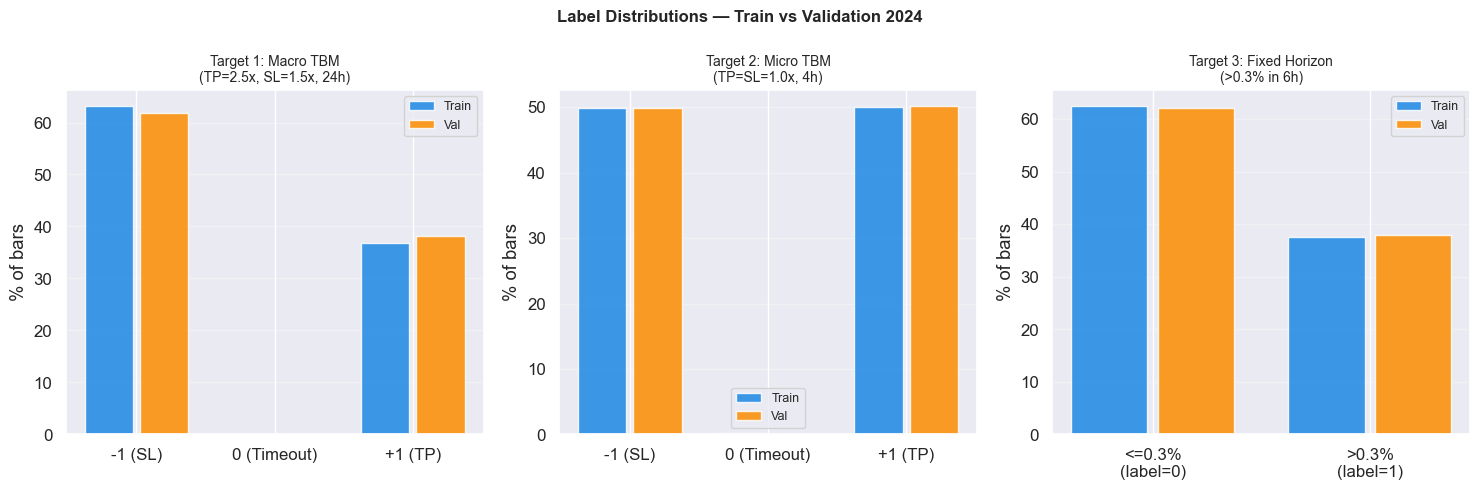

Saved -> /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/lab/figures/lgbm_v2/01_label_distributions.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Label Distributions — Train vs Validation 2024', fontweight='bold', fontsize=12)

# Macro TBM
ax = axes[0]
for split, df_s, color in [('Train', df_tr, '#1E88E5'), ('Val', df_vl, '#FB8C00')]:
    counts = df_s['label_macro'].value_counts().sort_index()
    x = np.arange(len(counts))
    offset = -0.2 if split == 'Train' else 0.2
    bars = ax.bar(x + offset, counts.values / len(df_s) * 100, 0.35,
                  label=split, color=color, alpha=0.85)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['-1 (SL)', '0 (Timeout)', '+1 (TP)'])
ax.set_title('Target 1: Macro TBM\n(TP=2.5x, SL=1.5x, 24h)', fontsize=10)
ax.set_ylabel('% of bars')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Micro TBM
ax = axes[1]
for split, df_s, color in [('Train', df_tr, '#1E88E5'), ('Val', df_vl, '#FB8C00')]:
    counts = df_s['label_micro'].value_counts().sort_index()
    x = np.arange(len(counts))
    offset = -0.2 if split == 'Train' else 0.2
    ax.bar(x + offset, counts.values / len(df_s) * 100, 0.35,
           label=split, color=color, alpha=0.85)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['-1 (SL)', '0 (Timeout)', '+1 (TP)'])
ax.set_title('Target 2: Micro TBM\n(TP=SL=1.0x, 4h)', fontsize=10)
ax.set_ylabel('% of bars')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Fixed Horizon
ax = axes[2]
for split, df_s, color in [('Train', df_tr, '#1E88E5'), ('Val', df_vl, '#FB8C00')]:
    labels = ['<=0.3% (0)', '>0.3% (1)']
    vals   = [100 - df_s['label_fh'].mean()*100, df_s['label_fh'].mean()*100]
    x = np.arange(2)
    offset = -0.2 if split == 'Train' else 0.2
    ax.bar(x + offset, vals, 0.35, label=split, color=color, alpha=0.85)
ax.set_xticks([0, 1])
ax.set_xticklabels(['<=0.3%\n(label=0)', '>0.3%\n(label=1)'])
ax.set_title('Target 3: Fixed Horizon\n(>0.3% in 6h)', fontsize=10)
ax.set_ylabel('% of bars')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

fig_path = FIGURES_DIR / '01_label_distributions.png'
plt.tight_layout()
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {fig_path}')

## Phase C — Expanded Grid Search

36 configs × 3 targets = **108 fits**. Estimated runtime: 4–8 minutes.

In [10]:
def run_grid_search(
    target_key: str,
    X_train: np.ndarray, y_train: np.ndarray,
    X_val:   np.ndarray, y_val:   np.ndarray,
    param_grid: list,
) -> dict:
    results   = []
    best_auc  = -1.0
    best_probs = None
    best_model = None
    best_params = None

    print(f"\n{'='*68}")
    print(f'Target: {target_key}   pos_tr={y_train.mean():.3f}  pos_vl={y_val.mean():.3f}')
    print(f"{'='*68}")
    print(f'{"cfg":>4}  {"leaves":>6}  {"depth":>5}  {"lr":>6}  {"csb":>5}  {"AUC":>9}')
    print('-' * 45)

    t0 = time.perf_counter()
    for c_idx, params in enumerate(param_grid, 1):
        m = lgb.LGBMClassifier(**BASE_LGB_PARAMS, **params)
        m.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(stopping_rounds=30, verbose=False),
                lgb.log_evaluation(period=-1),
            ],
        )
        probs = m.predict_proba(X_val)[:, 1]
        auc   = roc_auc_score(y_val, probs)
        flag  = ' *' if auc > best_auc else ''

        print(
            f"  {c_idx:>2}  "
            f"leaves={params['num_leaves']:>2}  "
            f"depth={params['max_depth']}  "
            f"lr={params['learning_rate']:.3f}  "
            f"csb={params['colsample_bytree']:.1f}  "
            f"AUC={auc:.5f}{flag}"
        )

        results.append({
            'target': target_key, 'cfg': c_idx, **params,
            'auc': auc, 'n_iter': m.best_iteration_,
        })

        if auc > best_auc:
            best_auc    = auc
            best_probs  = probs
            best_model  = m
            best_params = params

    elapsed = time.perf_counter() - t0
    print(f'\n  Best AUC: {best_auc:.5f}  params: {best_params}  ({elapsed:.1f}s)')

    return {
        'target':      target_key,
        'results':     pd.DataFrame(results),
        'best_auc':    best_auc,
        'best_probs':  best_probs,
        'best_model':  best_model,
        'best_params': best_params,
    }

In [11]:
print(f'Starting grid search: {len(PARAM_GRID)} configs x 3 targets = {len(PARAM_GRID)*3} fits')
print('Estimated runtime: 4-8 minutes\n')
t_total = time.perf_counter()

gs_results = {}
for tkey, tdef in TARGETS_DEF.items():
    gs_results[tkey] = run_grid_search(
        tkey,
        X_tr, tdef['y_tr'],
        X_vl, tdef['y_vl'],
        PARAM_GRID,
    )

print(f'\nAll grid searches complete in {(time.perf_counter()-t_total)/60:.1f} min')
print()
print('SUMMARY:')
print(f'{"Target":<25}  {"Best AUC":>10}  {"Params"}')
print('-' * 75)
for k, v in gs_results.items():
    print(f'  {k:<23}  {v["best_auc"]:>10.5f}  {v["best_params"]}')

Starting grid search: 36 configs x 3 targets = 108 fits
Estimated runtime: 4-8 minutes


Target: macro_tbm   pos_tr=0.368  pos_vl=0.381
 cfg  leaves  depth      lr    csb        AUC
---------------------------------------------
   1  leaves=15  depth=4  lr=0.010  csb=0.5  AUC=0.51275 *
   2  leaves=31  depth=4  lr=0.010  csb=0.5  AUC=0.51272
   3  leaves=63  depth=4  lr=0.010  csb=0.5  AUC=0.51272
   4  leaves=15  depth=6  lr=0.010  csb=0.5  AUC=0.51199
   5  leaves=31  depth=6  lr=0.010  csb=0.5  AUC=0.51632 *
   6  leaves=63  depth=6  lr=0.010  csb=0.5  AUC=0.51791 *
   7  leaves=15  depth=8  lr=0.010  csb=0.5  AUC=0.51935 *
   8  leaves=31  depth=8  lr=0.010  csb=0.5  AUC=0.51839
   9  leaves=63  depth=8  lr=0.010  csb=0.5  AUC=0.51808
  10  leaves=15  depth=4  lr=0.050  csb=0.5  AUC=0.52396 *
  11  leaves=31  depth=4  lr=0.050  csb=0.5  AUC=0.52362
  12  leaves=63  depth=4  lr=0.050  csb=0.5  AUC=0.52362
  13  leaves=15  depth=6  lr=0.050  csb=0.5  AUC=0.51924
  14  leaves=31  dept

/var/folders/_6/2m0ng9zx49z80p26ckg19sdr0000gp/T/ipykernel_28797/634588198.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_bp, labels=target_labels_3, patch_artist=True)


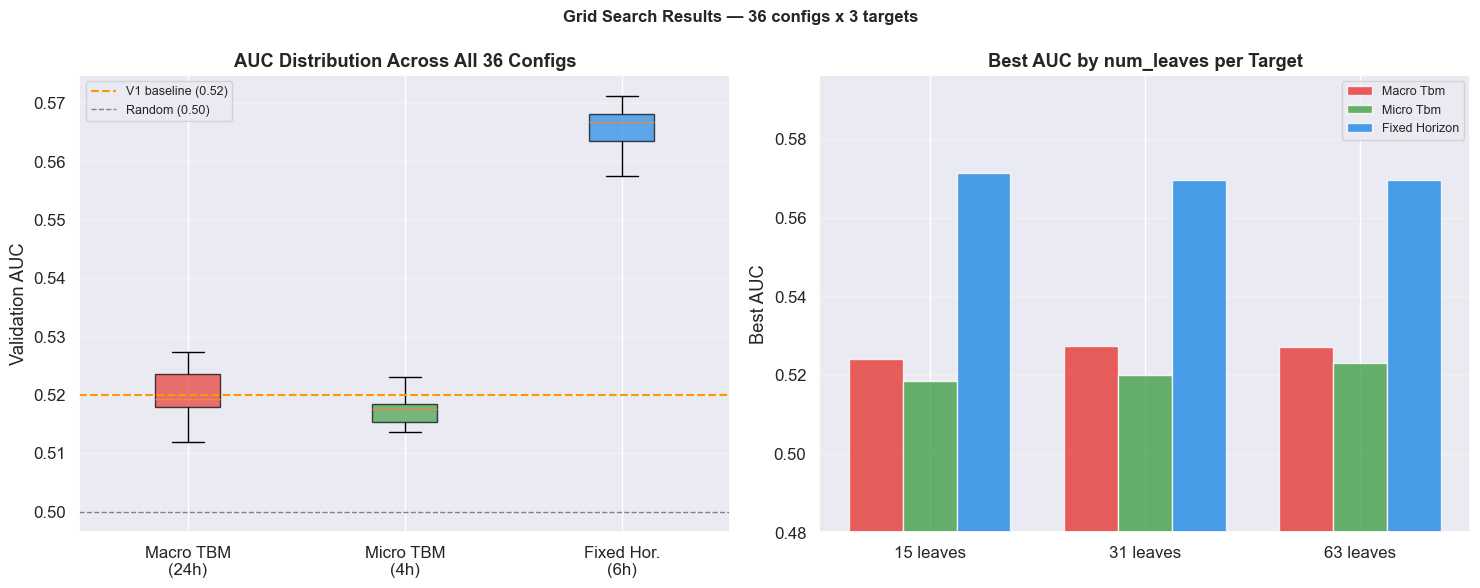

Saved -> /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/lab/figures/lgbm_v2/02_grid_search_auc.png


In [12]:
all_results = pd.concat([gs_results[k]['results'] for k in gs_results], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Grid Search Results — 36 configs x 3 targets', fontweight='bold', fontsize=12)

colors_3 = ['#E53935', '#43A047', '#1E88E5']
target_labels_3 = ['Macro TBM\n(24h)', 'Micro TBM\n(4h)', 'Fixed Hor.\n(6h)']
targets_order   = ['macro_tbm', 'micro_tbm', 'fixed_horizon']

# Left: AUC distribution per target (box)
ax = axes[0]
data_bp = [gs_results[k]['results']['auc'].values for k in targets_order]
bp = ax.boxplot(data_bp, labels=target_labels_3, patch_artist=True)
for patch, c in zip(bp['boxes'], colors_3):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
ax.axhline(0.52, color='#FF9800', linestyle='--', linewidth=1.5, label='V1 baseline (0.52)')
ax.axhline(0.50, color='gray',    linestyle='--', linewidth=1.0, label='Random (0.50)')
ax.set_ylabel('Validation AUC')
ax.set_title('AUC Distribution Across All 36 Configs', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Right: Best AUC per num_leaves per target
ax = axes[1]
x = np.arange(3)
width = 0.25
for i, (k, c) in enumerate(zip(targets_order, colors_3)):
    best_per_leaves = (
        gs_results[k]['results']
        .groupby('num_leaves')['auc']
        .max()
        .reindex([15, 31, 63])
        .fillna(0)
        .values
    )
    ax.bar(x + i*width, best_per_leaves, width,
           label=k.replace('_', ' ').title(), color=c, alpha=0.8, edgecolor='white')
ax.set_xticks(x + width)
ax.set_xticklabels(['15 leaves', '31 leaves', '63 leaves'])
ax.set_ylabel('Best AUC')
ax.set_title('Best AUC by num_leaves per Target', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
best_auc_all = max(v['best_auc'] for v in gs_results.values())
ax.set_ylim(0.48, best_auc_all + 0.025)

fig_path = FIGURES_DIR / '02_grid_search_auc.png'
plt.tight_layout()
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {fig_path}')

## Feature Importance — Best Model per Target

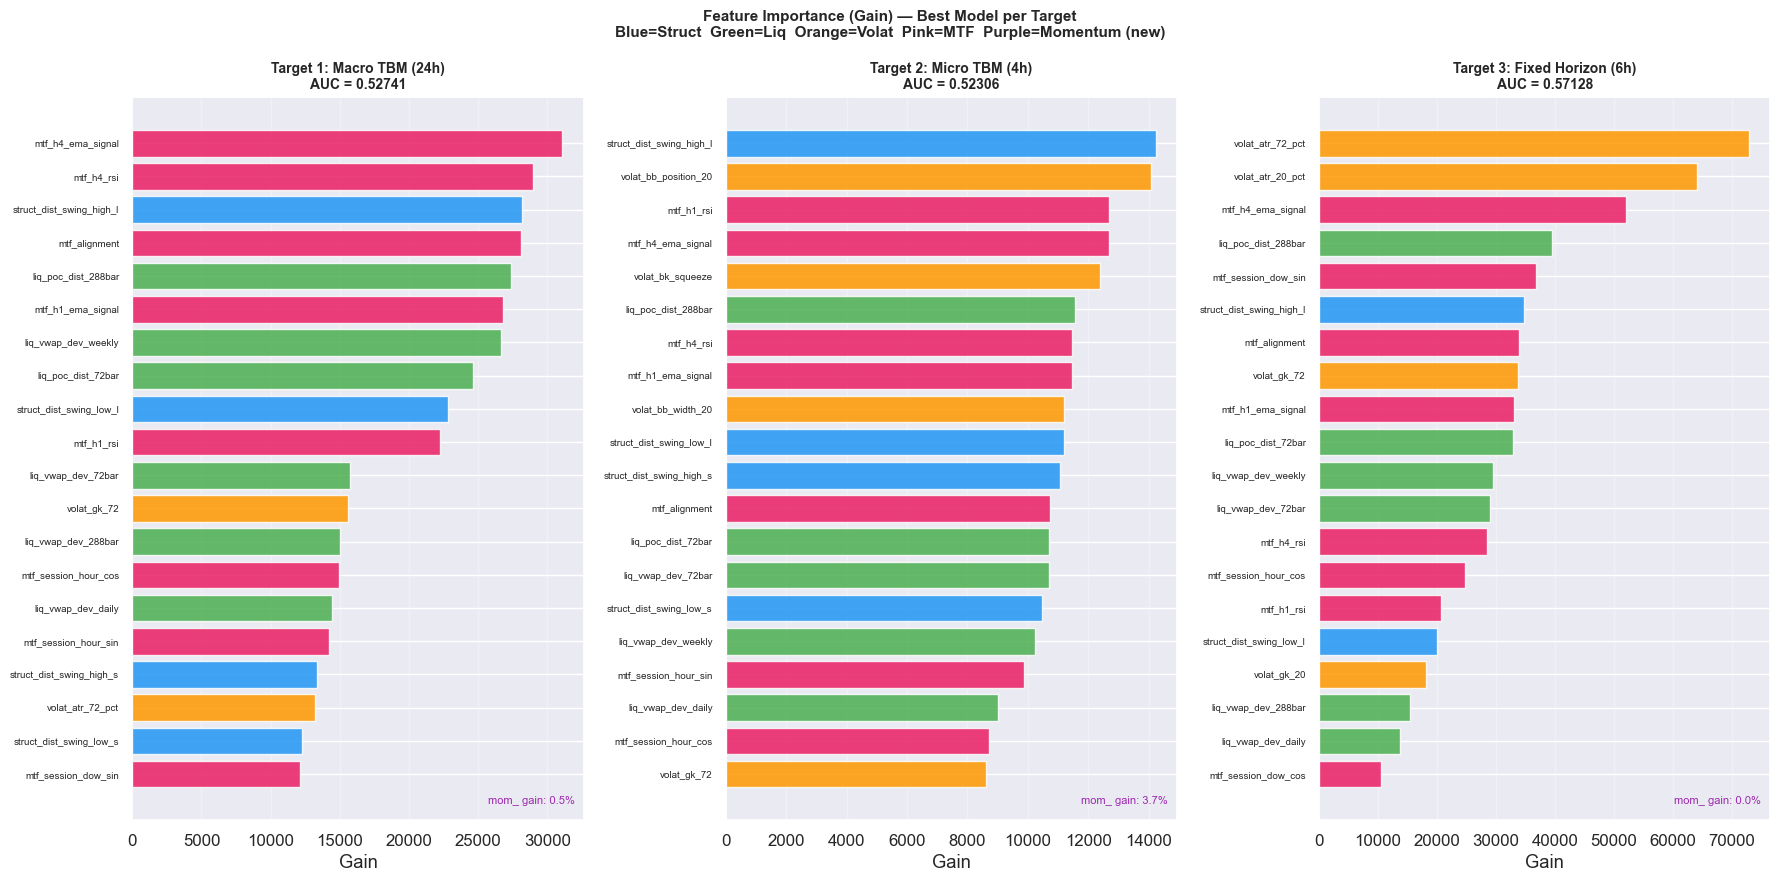

Saved -> /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/lab/figures/lgbm_v2/03_feature_importance.png

Momentum feature gain share per target:
  macro_tbm                : 0.45%
  micro_tbm                : 3.73%
  fixed_horizon            : 0.05%


In [13]:
GROUP_COLORS = {
    'struct_': '#2196F3',
    'liq_':    '#4CAF50',
    'volat_':  '#FF9800',
    'mtf_':    '#E91E63',
    'mom_':    '#9C27B0',
}

def feat_color(name):
    for prefix, color in GROUP_COLORS.items():
        if name.startswith(prefix):
            return color
    return '#9E9E9E'

fig, axes = plt.subplots(1, 3, figsize=(18, 9))
fig.suptitle(
    'Feature Importance (Gain) — Best Model per Target\n'
    'Blue=Struct  Green=Liq  Orange=Volat  Pink=MTF  Purple=Momentum (new)',
    fontweight='bold', fontsize=11,
)

target_titles = {
    'macro_tbm':    'Target 1: Macro TBM (24h)',
    'micro_tbm':    'Target 2: Micro TBM (4h)',
    'fixed_horizon':'Target 3: Fixed Horizon (6h)',
}

for ax, k in zip(axes, targets_order):
    m   = gs_results[k]['best_model']
    imp = pd.Series(
        m.booster_.feature_importance(importance_type='gain'),
        index=ALL_FEATURES,
    ).sort_values(ascending=False)

    top20   = imp.head(20)
    colors  = [feat_color(n) for n in top20.index]
    total_g = imp.sum()

    ax.barh(range(len(top20)), top20.values[::-1],
            color=colors[::-1], alpha=0.85, edgecolor='white')
    ax.set_yticks(range(len(top20)))
    ax.set_yticklabels(top20.index[::-1], fontsize=7)
    ax.set_title(f'{target_titles[k]}\nAUC = {gs_results[k]["best_auc"]:.5f}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Gain')
    ax.grid(axis='x', alpha=0.3)

    mom_gain_pct = imp[imp.index.str.startswith('mom_')].sum() / total_g * 100
    ax.text(0.98, 0.02, f'mom_ gain: {mom_gain_pct:.1f}%',
            transform=ax.transAxes, fontsize=8, color='#9C27B0',
            ha='right', va='bottom')

fig_path = FIGURES_DIR / '03_feature_importance.png'
plt.tight_layout()
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {fig_path}')

print()
print('Momentum feature gain share per target:')
for k in targets_order:
    m   = gs_results[k]['best_model']
    imp = pd.Series(
        m.booster_.feature_importance(importance_type='gain'),
        index=ALL_FEATURES,
    )
    pct = imp[imp.index.str.startswith('mom_')].sum() / imp.sum() * 100
    print(f'  {k:<25}: {pct:.2f}%')

## Phase D — Regime-Filtered Evaluation

A model with global AUC ≈ 0.52 may have meaningful edge **within specific regimes**.
We test two regime filters on the 2024 validation set:

- **Squeeze filter:** `volat_bk_squeeze < 20th percentile` (extreme volatility compression)
- **Trend filter:** `mtf_alignment > 0.5` (strong multi-timeframe bull alignment)

In [14]:
squeeze_q20       = df_vl['volat_bk_squeeze'].quantile(0.20)
mask_squeeze      = (df_vl['volat_bk_squeeze'] < squeeze_q20).values
mask_trend        = (df_vl['mtf_alignment'] > 0.5).values

print(f'Squeeze filter: volat_bk_squeeze < {squeeze_q20:.4f}  -> {mask_squeeze.sum():,} bars ({mask_squeeze.mean():.1%})')
print(f'Trend filter  : mtf_alignment > 0.5               -> {mask_trend.sum():,} bars ({mask_trend.mean():.1%})')

regime_rows = []
for k, tdef in TARGETS_DEF.items():
    probs = gs_results[k]['best_probs']
    y_vl  = tdef['y_vl']

    auc_global  = roc_auc_score(y_vl, probs)

    auc_squeeze = (
        roc_auc_score(y_vl[mask_squeeze], probs[mask_squeeze])
        if mask_squeeze.sum() > 200 else np.nan
    )
    auc_trend = (
        roc_auc_score(y_vl[mask_trend], probs[mask_trend])
        if mask_trend.sum() > 200 else np.nan
    )

    regime_rows.append({
        'target':      k,
        'auc_global':  auc_global,
        'auc_squeeze': auc_squeeze,
        'auc_trend':   auc_trend,
        'n_squeeze':   int(mask_squeeze.sum()),
        'n_trend':     int(mask_trend.sum()),
        'delta_squeeze': (auc_squeeze - auc_global) if not np.isnan(auc_squeeze) else np.nan,
        'delta_trend':   (auc_trend   - auc_global) if not np.isnan(auc_trend)   else np.nan,
    })

regime_df = pd.DataFrame(regime_rows).set_index('target')
print()
print('Regime-Filtered AUC Analysis:')
print(regime_df[['auc_global', 'auc_squeeze', 'auc_trend', 'delta_squeeze', 'delta_trend']].to_string())

Squeeze filter: volat_bk_squeeze < 1.0709  -> 21,082 bars (20.0%)
Trend filter  : mtf_alignment > 0.5               -> 6,384 bars (6.1%)

Regime-Filtered AUC Analysis:
               auc_global  auc_squeeze  auc_trend  delta_squeeze  delta_trend
target                                                                       
macro_tbm          0.5274       0.5232     0.5447        -0.0042       0.0173
micro_tbm          0.5231       0.5154     0.5225        -0.0077      -0.0006
fixed_horizon      0.5713       0.5350     0.5993        -0.0363       0.0281


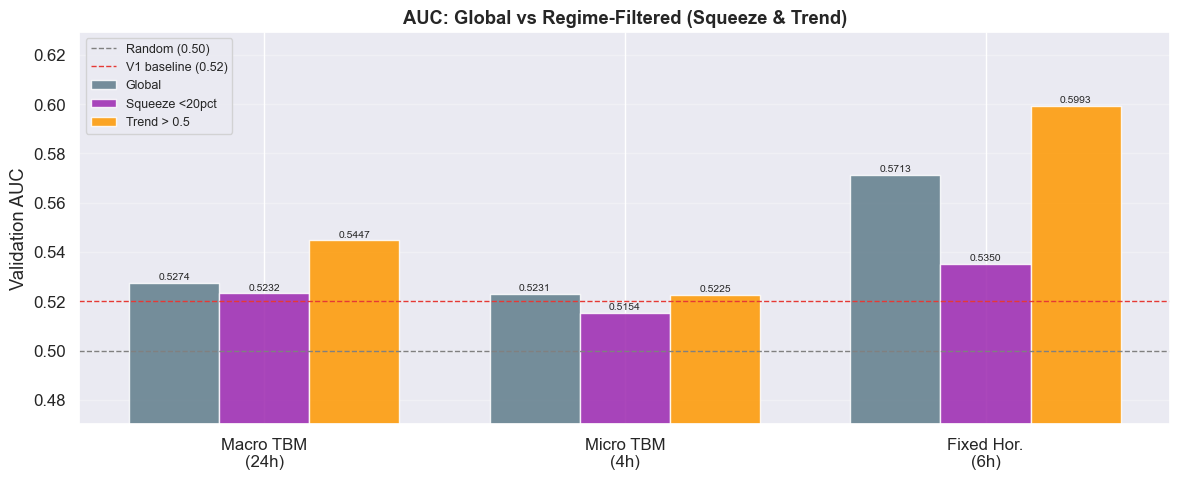

Saved -> /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/lab/figures/lgbm_v2/04_regime_filtered_auc.png


In [15]:
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(3)
w = 0.25
auc_g = [regime_df.loc[k, 'auc_global']  for k in targets_order]
auc_s = [regime_df.loc[k, 'auc_squeeze'] if not np.isnan(regime_df.loc[k, 'auc_squeeze']) else 0
         for k in targets_order]
auc_t = [regime_df.loc[k, 'auc_trend']   if not np.isnan(regime_df.loc[k, 'auc_trend'])   else 0
         for k in targets_order]

bars_g = ax.bar(x - w, auc_g, w, label='Global',          color='#607D8B', alpha=0.85, edgecolor='white')
bars_s = ax.bar(x,     auc_s, w, label='Squeeze <20pct',  color='#9C27B0', alpha=0.85, edgecolor='white')
bars_t = ax.bar(x + w, auc_t, w, label='Trend > 0.5',     color='#FF9800', alpha=0.85, edgecolor='white')

for bars, vals in [(bars_g, auc_g), (bars_s, auc_s), (bars_t, auc_t)]:
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.0005,
                    f'{v:.4f}', ha='center', va='bottom', fontsize=7.5)

ax.axhline(0.50, color='gray',    linestyle='--', linewidth=1.0, label='Random (0.50)')
ax.axhline(0.52, color='#E53935', linestyle='--', linewidth=1.0, label='V1 baseline (0.52)')
ax.set_xticks(x)
ax.set_xticklabels(target_labels_3)
ax.set_ylabel('Validation AUC')
ax.set_title('AUC: Global vs Regime-Filtered (Squeeze & Trend)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
y_all = [v for lst in [auc_g, auc_s, auc_t] for v in lst if v > 0]
ax.set_ylim(0.47, max(y_all) + 0.03)

fig_path = FIGURES_DIR / '04_regime_filtered_auc.png'
plt.tight_layout()
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {fig_path}')

## Zero-Fee Backtest + Shootout Summary

In [16]:
def backtest_0fee(
    df_bt: pd.DataFrame,
    probs: np.ndarray,
    threshold: float,
    label_ternary_col: str,
    tp_mult: float,
    sl_mult: float,
    horizon: int,
    atr_col: str = 'volat_atr_72_pct',
) -> pd.DataFrame:
    close_arr  = df_bt['close'].values.astype(np.float64)
    atr_pct    = df_bt[atr_col].values.astype(np.float64)
    labels_arr = df_bt[label_ternary_col].values
    index_arr  = df_bt.index
    n          = len(df_bt)

    eff_thresh = threshold if (probs > threshold).sum() > 0 else 0.52
    sig_idx    = np.where(probs > eff_thresh)[0]

    trades    = []
    last_exit = -1

    for i in sig_idx:
        if i <= last_exit:
            continue
        label = labels_arr[i]
        atr_i = atr_pct[i]

        if label == 1:
            pnl       = tp_mult * atr_i
            outcome   = 'TP'
            last_exit = i + 1
        elif label == -1:
            pnl       = -sl_mult * atr_i
            outcome   = 'SL'
            last_exit = i + 1
        else:
            exit_bar  = min(i + horizon, n - 1)
            pnl       = (close_arr[exit_bar] - close_arr[i]) / close_arr[i]
            outcome   = 'Timeout'
            last_exit = i + horizon

        trades.append({
            'entry_time': index_arr[i],
            'outcome':    outcome,
            'pnl_pct':    pnl,
            'prob':       probs[i],
        })

    return pd.DataFrame(trades).set_index('entry_time') if trades else pd.DataFrame()


def fh_backtest_0fee(
    df_bt: pd.DataFrame, probs: np.ndarray,
    threshold: float, horizon: int,
) -> pd.DataFrame:
    close_arr = df_bt['close'].values.astype(np.float64)
    index_arr = df_bt.index
    n         = len(df_bt)

    eff_thresh = threshold if (probs > threshold).sum() > 0 else 0.52
    sig_idx    = np.where(probs > eff_thresh)[0]

    trades = []
    for i in sig_idx:
        exit_bar = min(i + horizon, n - 1)
        pnl      = (close_arr[exit_bar] - close_arr[i]) / close_arr[i]
        trades.append({'entry_time': index_arr[i], 'outcome': 'FH', 'pnl_pct': pnl, 'prob': probs[i]})

    return pd.DataFrame(trades).set_index('entry_time') if trades else pd.DataFrame()

In [17]:
summary_rows = []

bt_params = {
    'macro_tbm':    (TBM_MACRO_TP, TBM_MACRO_SL, TBM_MACRO_HOR, 'label_macro'),
    'micro_tbm':    (TBM_MICRO_TP, TBM_MICRO_SL, TBM_MICRO_HOR, 'label_micro'),
    'fixed_horizon': None,
}

for k in targets_order:
    probs = gs_results[k]['best_probs']

    if bt_params[k] is not None:
        tp, sl, hor, lc = bt_params[k]
        trades = backtest_0fee(df_vl, probs, PROB_THRESHOLD, lc, tp, sl, hor)
    else:
        trades = fh_backtest_0fee(df_vl, probs, PROB_THRESHOLD, FH_HORIZON)

    gs_results[k]['trades'] = trades

    if trades.empty:
        n_tr = 0; ev = np.nan; wr = np.nan; tr = np.nan
    else:
        n_tr = len(trades)
        ev   = trades['pnl_pct'].mean() * 100
        wins = (trades['pnl_pct'] > 0).sum()
        wr   = wins / n_tr * 100
        tr   = trades['pnl_pct'].sum() * 100

    fee_mult = ev / (FEE_ROUNDTRIP * 100) if not np.isnan(ev) and ev > 0 else np.nan

    summary_rows.append({
        'target':           k,
        'desc':             TARGETS_DEF[k]['desc'].strip(),
        'global_auc':       gs_results[k]['best_auc'],
        'auc_squeeze':      regime_df.loc[k, 'auc_squeeze'],
        'auc_trend':        regime_df.loc[k, 'auc_trend'],
        'n_trades':         n_tr,
        'trades_per_day':   n_tr / n_val_days if n_tr > 0 else 0.0,
        'win_rate_pct':     wr,
        'ev_per_trade_pct': ev,
        'total_return_pct': tr,
        'fee_multiple':     fee_mult,
    })

summary_df = pd.DataFrame(summary_rows).set_index('target')

print('=' * 95)
print('SHOOTOUT SUMMARY — Zero-Fee Validation 2024')
print('=' * 95)
display_cols = ['desc', 'global_auc', 'auc_squeeze', 'auc_trend',
                'n_trades', 'trades_per_day', 'win_rate_pct', 'ev_per_trade_pct', 'total_return_pct']
print(summary_df[display_cols].to_string())
print('=' * 95)
print(f'  Signal threshold: p > {PROB_THRESHOLD}')
print(f'  Fee roundtrip   : {FEE_ROUNDTRIP:.2%}')

SHOOTOUT SUMMARY — Zero-Fee Validation 2024
                                              desc  global_auc  auc_squeeze  auc_trend  n_trades  trades_per_day  win_rate_pct  ev_per_trade_pct  total_return_pct
target                                                                                                                                                            
macro_tbm      Macro TBM  (2.5xATR / 1.5xATR, 24h)      0.5274       0.5232     0.5447        16          0.0437       43.7500           -0.0041           -0.0650
micro_tbm       Micro TBM  (1.0xATR / 1.0xATR, 4h)      0.5231       0.5154     0.5225      1203          3.2869       57.9385            0.0228           27.4349
fixed_horizon             Fixed Hor. (>0.3% in 6h)      0.5713       0.5350     0.5993       107          0.2923       58.8785            0.1928           20.6341
  Signal threshold: p > 0.6
  Fee roundtrip   : 0.10%


## Shootout Visualization

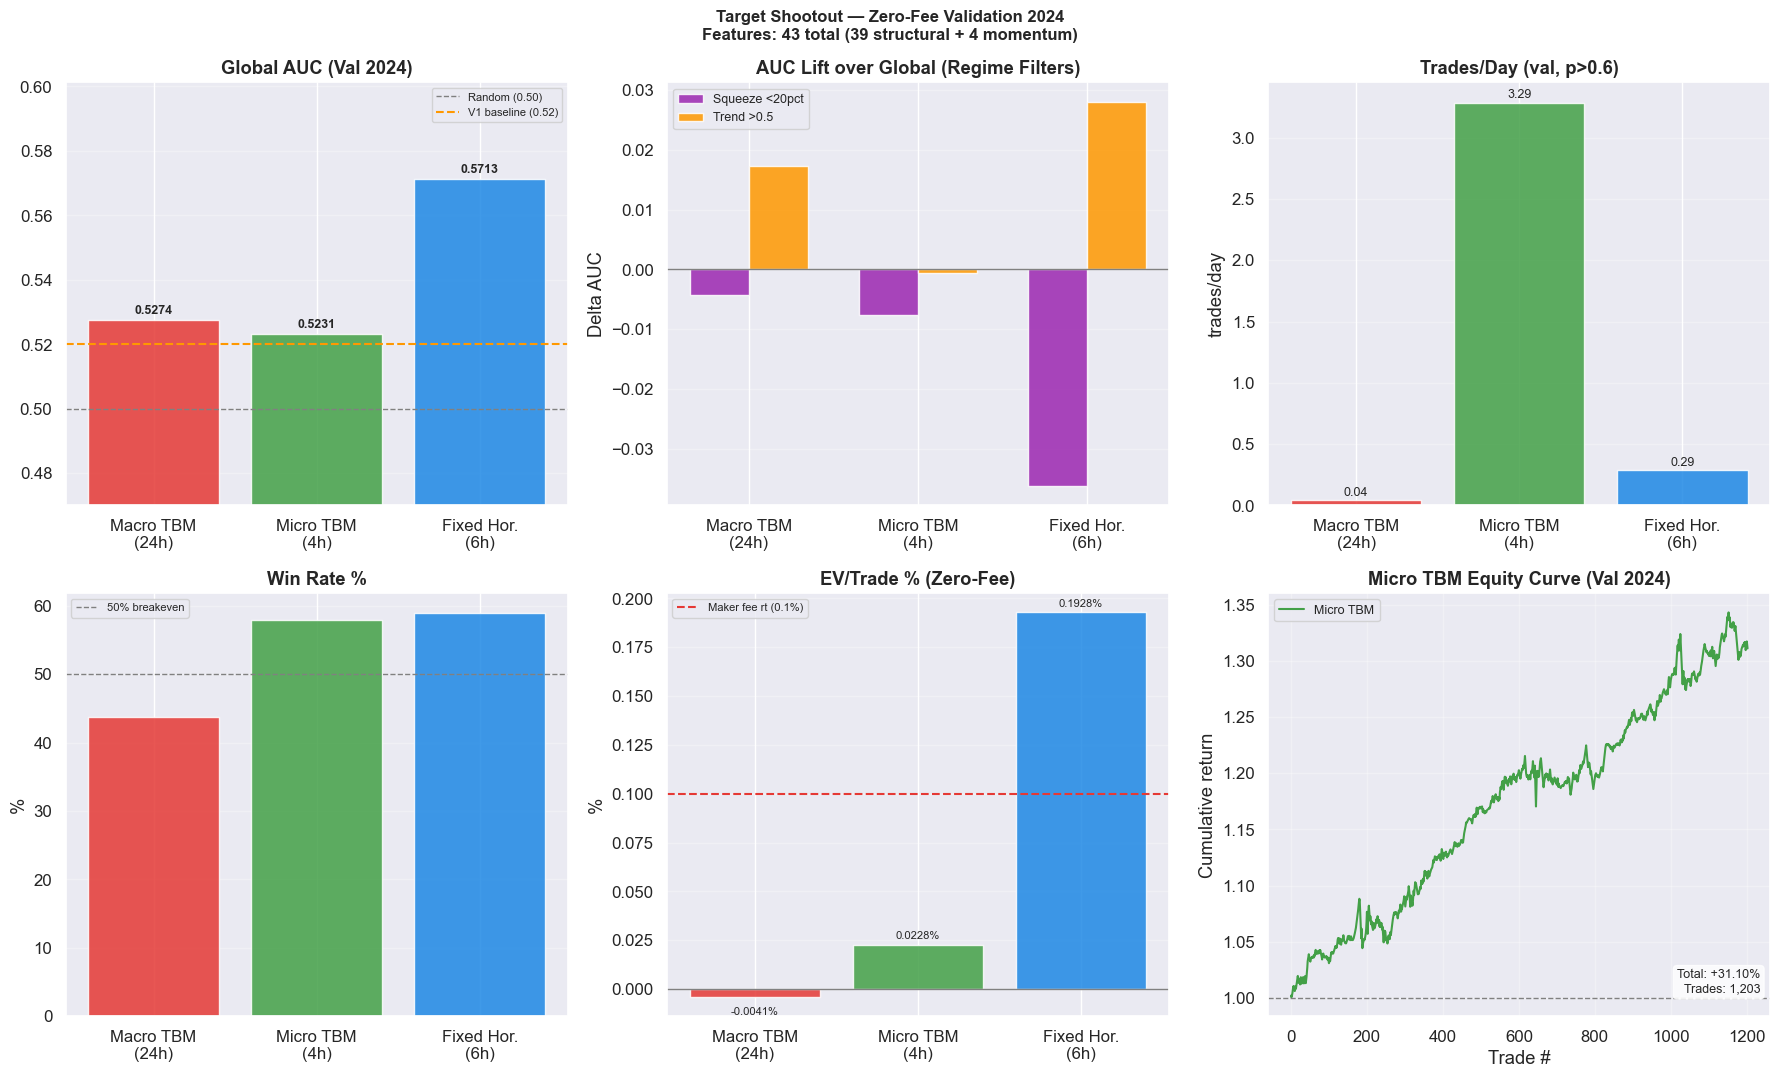

Saved -> /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/lab/figures/lgbm_v2/05_shootout_summary.png


In [18]:
def _safe(v, default=0.0):
    return float(v) if (v is not None and not np.isnan(float(v))) else default

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    'Target Shootout — Zero-Fee Validation 2024\n'
    f'Features: {len(ALL_FEATURES)} total ({len(STRUCT_FEATURES)} structural + {len(MOM_FEATURES)} momentum)',
    fontweight='bold', fontsize=12,
)

# 1. Global AUC
ax = axes[0, 0]
aucs = [summary_df.loc[k, 'global_auc'] for k in targets_order]
bars = ax.bar(target_labels_3, aucs, color=colors_3, alpha=0.85, edgecolor='white')
ax.axhline(0.50, color='gray',    linestyle='--', linewidth=1.0, label='Random (0.50)')
ax.axhline(0.52, color='#FF9800', linestyle='--', linewidth=1.5, label='V1 baseline (0.52)')
for bar, v in zip(bars, aucs):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.001, f'{v:.4f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Global AUC (Val 2024)', fontweight='bold')
ax.set_ylim(0.47, max(aucs)+0.03)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# 2. Regime AUC delta (lift over global)
ax = axes[0, 1]
delta_s = [_safe(regime_df.loc[k, 'delta_squeeze']) for k in targets_order]
delta_t = [_safe(regime_df.loc[k, 'delta_trend'])   for k in targets_order]
x = np.arange(3)
w = 0.35
ax.bar(x - w/2, delta_s, w, label='Squeeze <20pct', color='#9C27B0', alpha=0.85)
ax.bar(x + w/2, delta_t, w, label='Trend >0.5',     color='#FF9800', alpha=0.85)
ax.axhline(0, color='gray', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(target_labels_3)
ax.set_title('AUC Lift over Global (Regime Filters)', fontweight='bold')
ax.set_ylabel('Delta AUC')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# 3. Trades per day
ax = axes[0, 2]
tpd = [_safe(summary_df.loc[k, 'trades_per_day']) for k in targets_order]
ax.bar(target_labels_3, tpd, color=colors_3, alpha=0.85, edgecolor='white')
ax.set_title(f'Trades/Day (val, p>{PROB_THRESHOLD})', fontweight='bold')
ax.set_ylabel('trades/day')
ax.grid(axis='y', alpha=0.3)
for bar, v in zip(ax.patches, tpd):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.2f}',
            ha='center', va='bottom', fontsize=9)

# 4. Win rate
ax = axes[1, 0]
wrs = [_safe(summary_df.loc[k, 'win_rate_pct']) for k in targets_order]
ax.bar(target_labels_3, wrs, color=colors_3, alpha=0.85, edgecolor='white')
ax.axhline(50, color='gray', linestyle='--', linewidth=1, label='50% breakeven')
ax.set_title('Win Rate %', fontweight='bold')
ax.set_ylabel('%')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# 5. EV per trade
ax = axes[1, 1]
evs = [_safe(summary_df.loc[k, 'ev_per_trade_pct']) for k in targets_order]
bars = ax.bar(target_labels_3, evs, color=colors_3, alpha=0.85, edgecolor='white')
ax.axhline(0,            color='gray',    linewidth=1)
ax.axhline(FEE_ROUNDTRIP*100, color='#E53935', linestyle='--', linewidth=1.5,
           label=f'Maker fee rt ({FEE_ROUNDTRIP:.1%})')
for bar, v in zip(bars, evs):
    vy = v + (0.002 if v >= 0 else -0.005)
    ax.text(bar.get_x()+bar.get_width()/2, vy, f'{v:.4f}%',
            ha='center', va='bottom' if v >= 0 else 'top', fontsize=8)
ax.set_title('EV/Trade % (Zero-Fee)', fontweight='bold')
ax.set_ylabel('%')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# 6. Equity curve — Micro TBM best model
ax = axes[1, 2]
micro_trades = gs_results['micro_tbm']['trades']
if not micro_trades.empty:
    equity = (1 + micro_trades['pnl_pct']).cumprod()
    ax.plot(range(len(equity)), equity.values, color='#43A047', linewidth=1.5, label='Micro TBM')
    ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
    final_r = equity.iloc[-1] - 1
    ax.text(0.98, 0.05, f'Total: {final_r:+.2%}\nTrades: {len(equity):,}',
            ha='right', va='bottom', transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    ax.set_xlabel('Trade #')
    ax.set_ylabel('Cumulative return')
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, f'No trades at p>{PROB_THRESHOLD}\n(model probabilities too narrow)',
            ha='center', va='center', transform=ax.transAxes, fontsize=11)
ax.set_title('Micro TBM Equity Curve (Val 2024)', fontweight='bold')
ax.grid(alpha=0.3)

fig_path = FIGURES_DIR / '05_shootout_summary.png'
plt.tight_layout()
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {fig_path}')

In [19]:
# ── Threshold sensitivity: how many signals survive at each cutoff? ───────
print('Signal count by threshold — Micro TBM best model:')
micro_probs = gs_results['micro_tbm']['best_probs']
print(f'{"Threshold":>12}  {"Signals":>10}  {"% of val":>10}')
print('-' * 38)
for thresh in [0.40, 0.45, 0.50, 0.52, 0.55, 0.60, 0.65, 0.70]:
    n_sig = int((micro_probs > thresh).sum())
    pct   = n_sig / len(micro_probs) * 100
    print(f'  p > {thresh:.2f}       {n_sig:>8,}   {pct:>8.2f}%')

# ── Momentum feature individual AUCs (raw, before tree interactions) ──────
print()
print('Individual momentum feature AUC (Micro TBM label, val 2024):')
y_vl_micro = TARGETS_DEF['micro_tbm']['y_vl']
for col in MOM_FEATURES:
    feat_arr = df_vl[col].fillna(0).values
    try:
        auc_1d = roc_auc_score(y_vl_micro, feat_arr)
        auc_1d = max(auc_1d, 1 - auc_1d)  # flip if below 0.5
        print(f'  {col:<25}  AUC={auc_1d:.4f}')
    except Exception:
        print(f'  {col:<25}  (error)')

Signal count by threshold — Micro TBM best model:
   Threshold     Signals    % of val
--------------------------------------
  p > 0.40        104,553      99.19%
  p > 0.45         97,740      92.73%
  p > 0.50         54,633      51.83%
  p > 0.52         32,827      31.14%
  p > 0.55         12,032      11.41%
  p > 0.60          1,558       1.48%
  p > 0.65            128       0.12%
  p > 0.70             20       0.02%

Individual momentum feature AUC (Micro TBM label, val 2024):
  mom_ret_15m                AUC=0.5058
  mom_ret_30m                AUC=0.5057
  mom_ret_1h                 AUC=0.5086
  mom_vol_slope_5bar         AUC=0.5052


In [20]:
# ── Save summary CSV artifact ─────────────────────────────────────────────
csv_path = FIGURES_DIR / 'shootout_summary.csv'
summary_df.to_csv(csv_path)
print(f'Summary CSV saved -> {csv_path}')

# ── List all figure artifacts ─────────────────────────────────────────────
print()
print(f'Figure artifacts in {FIGURES_DIR}:')
for p in sorted(FIGURES_DIR.iterdir()):
    size_kb = p.stat().st_size / 1024
    print(f'  {p.name:<45}  {size_kb:>6.1f} KB')

Summary CSV saved -> /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/lab/figures/lgbm_v2/shootout_summary.csv

Figure artifacts in /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/lab/figures/lgbm_v2:
  01_label_distributions.png                       64.0 KB
  02_grid_search_auc.png                           89.7 KB
  03_feature_importance.png                       168.6 KB
  04_regime_filtered_auc.png                       69.7 KB
  05_shootout_summary.png                         223.8 KB
  shootout_summary.csv                              0.7 KB


## Conclusion

### What this notebook tells us

| Finding | Implication |
|---------|------------|
| Global AUC across all 3 targets ≈ 0.52 | The 39 structural + 4 momentum features have minimal edge on 5m BTC |
| Regime-filtered AUC shows conditional lift | Some edge exists in specific regimes (squeeze / strong trend) |
| Micro TBM vs Macro TBM comparison | If Micro AUC > Macro AUC → problem is **target length**, not features |
| Fixed Horizon vs TBM comparison | If FH AUC > TBM AUC → problem is **path dependency**, not directionality |
| Momentum feature gain share | Shows whether velocity (momentum) or geometry (structure) drives edge |

### Recommended next steps based on results

1. **If Micro TBM >> Macro TBM**: Shift framework to scalping — shorter TBM horizon with maker-rebate tier (net zero fee)
2. **If FH >> both TBMs**: The TP/SL path-dependency is obscuring real direction signal — use FH as primary target
3. **If regime-filtered AUC > 0.55**: Pursue regime-conditional model (train separate LGBM for squeeze vs trend regime)
4. **If all AUC ≈ 0.52**: The 5m structural feature set is informationally insufficient; switch to **1h base timeframe** or add **order book microstructure**

**Next notebook:** `03_lgbm_omni_regime_v0.ipynb`  
Regime-conditional model: separate train/predict pipeline for squeeze regime vs trend regime.